In [3]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

# Display plots inside notebook
%matplotlib inline

In [4]:
# Load dataset

df = pd.read_csv("Data/Telco_customer_churn.csv")

# Display first five rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 33)


In [8]:
# Display all column names

print("Columns in the dataset:\n")
print(df.columns.tolist())

Columns in the dataset:

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [9]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing Values:\n")
missing_values

Missing Values:



CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [10]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [11]:
# Summary statistics for numerical columns

df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [28]:
# Distribution of the target variable
df['Churn Label'].value_counts()

No     5174
Yes    1869
Name: Churn Label, dtype: int64

In [29]:
# Percentage distribution of churn
df['Churn Label'].value_counts(normalize=True) * 100

No     73.463013
Yes    26.536987
Name: Churn Label, dtype: float64

In [30]:
# Display value counts for categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{'='*40}")
    print(col)
    print(df[col].value_counts())


CustomerID
4829-AUOAX    1
7157-SMCFK    1
1579-KLYDT    1
9095-HFAFX    1
4283-IVYCI    1
             ..
3726-TBHQT    1
8290-YWKHZ    1
2696-ECXKC    1
8785-CJSHH    1
1122-JWTJW    1
Name: CustomerID, Length: 7043, dtype: int64

Country
United States    7043
Name: Country, dtype: int64

State
California    7043
Name: State, dtype: int64

City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Loomis             4
Lone Pine          4
Westport           4
Lamont             4
Dunlap             4
Name: City, Length: 1129, dtype: int64

Lat Long
34.196837, -118.142236    5
32.984395, -117.013454    5
34.019323, -118.391902    5
33.897122, -118.164432    5
34.063947, -118.383001    5
                         ..
38.166791, -121.14207     4
34.067699, -116.903891    4
36.600193, -120.153393    4
36.633498, -119.298895    4
39.043387, -121.409837    4
Name: Lat Long, Length: 1652, dtype: int64

Gender
Male      3

In [31]:
# Display statistics for numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    print(f"\n{'='*40}")
    print(col)
    print(df[col].describe())


Count
count    7043.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Count, dtype: float64

Zip Code
count     7043.000000
mean     93521.964646
std       1865.794555
min      90001.000000
25%      92102.000000
50%      93552.000000
75%      95351.000000
max      96161.000000
Name: Zip Code, dtype: float64

Latitude
count    7043.000000
mean       36.282441
std         2.455723
min        32.555828
25%        34.030915
50%        36.391777
75%        38.224869
max        41.962127
Name: Latitude, dtype: float64

Longitude
count    7043.000000
mean     -119.798880
std         2.157889
min      -124.301372
25%      -121.815412
50%      -119.730885
75%      -118.043237
max      -114.192901
Name: Longitude, dtype: float64

Tenure Months
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Mont

In [32]:
# Number of unique values in each column
df.nunique().sort_values(ascending=False)

CustomerID           7043
Total Charges        6531
CLTV                 3438
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Monthly Charges      1585
City                 1129
Churn Score            85
Tenure Months          73
Churn Reason           20
Payment Method          4
Tech Support            3
Streaming Movies        3
Contract                3
Device Protection       3
Internet Service        3
Multiple Lines          3
Streaming TV            3
Online Security         3
Online Backup           3
Phone Service           2
Dependents              2
Partner                 2
Gender                  2
Paperless Billing       2
Churn Label             2
Churn Value             2
Senior Citizen          2
State                   1
Country                 1
Count                   1
dtype: int64

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

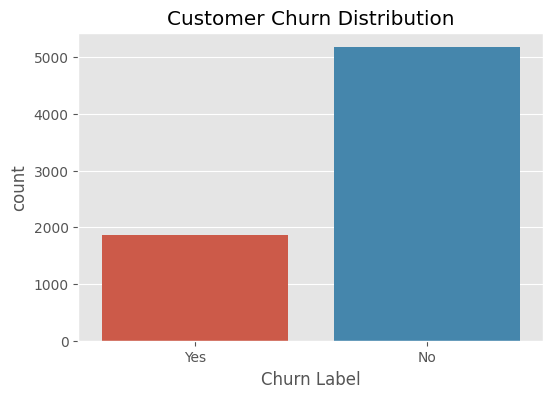

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn Label', data=df)
plt.title("Customer Churn Distribution")
plt.show()

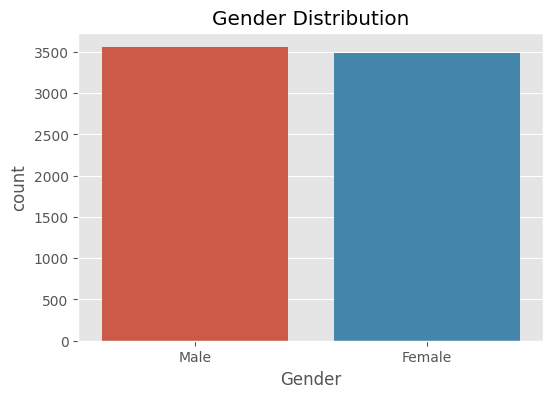

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

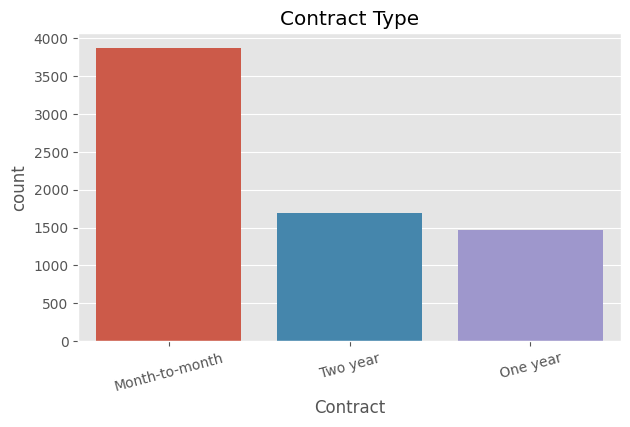

In [36]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', data=df)
plt.title("Contract Type")
plt.xticks(rotation=15)
plt.show()

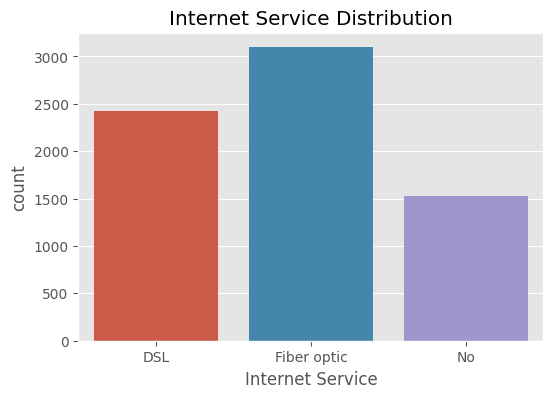

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Internet Service', data=df)
plt.title("Internet Service Distribution")
plt.show()

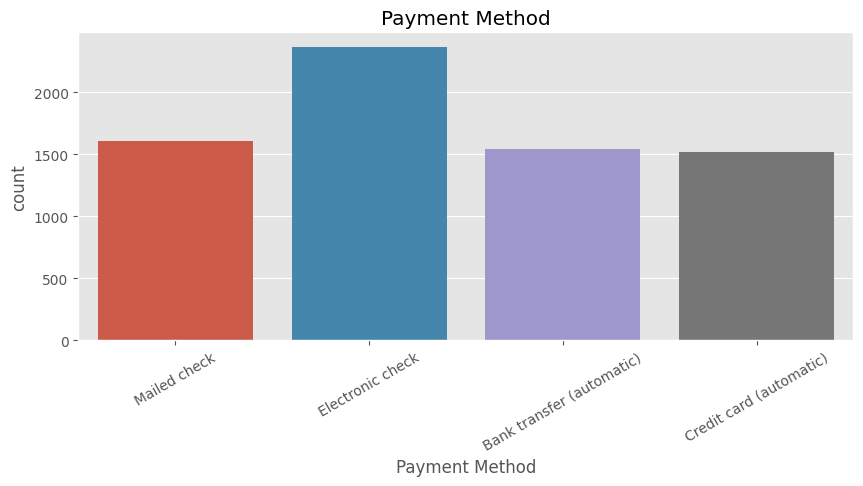

In [38]:
plt.figure(figsize=(10,4))
sns.countplot(x='Payment Method', data=df)
plt.title("Payment Method")
plt.xticks(rotation=30)
plt.show()

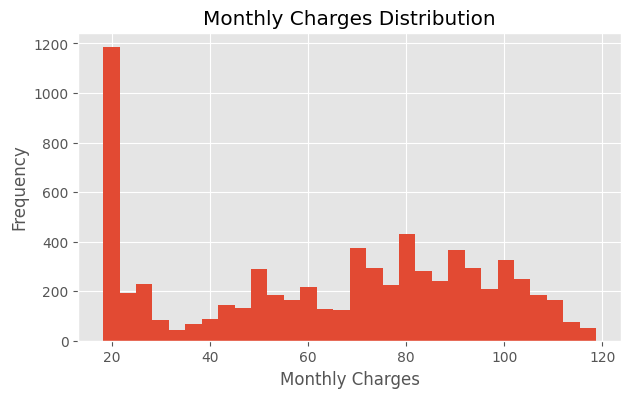

In [39]:
plt.figure(figsize=(7,4))
plt.hist(df['Monthly Charges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

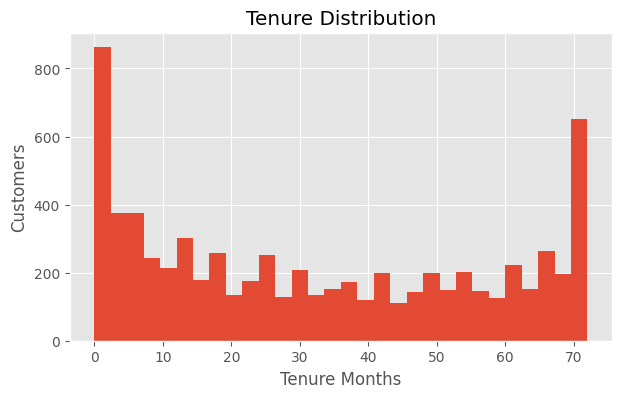

In [40]:
plt.figure(figsize=(7,4))
plt.hist(df['Tenure Months'], bins=30)
plt.title("Tenure Distribution")
plt.xlabel("Tenure Months")
plt.ylabel("Customers")
plt.show()

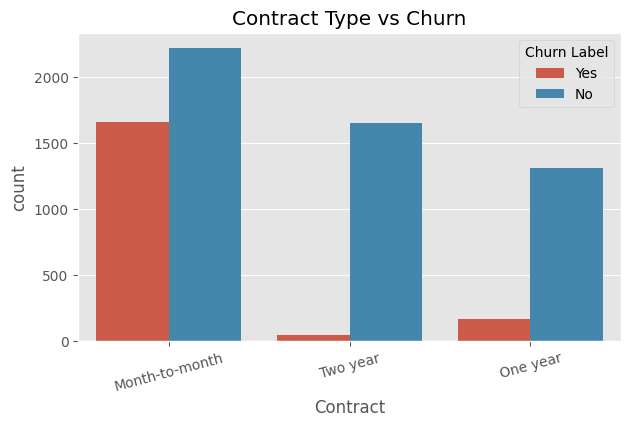

In [41]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

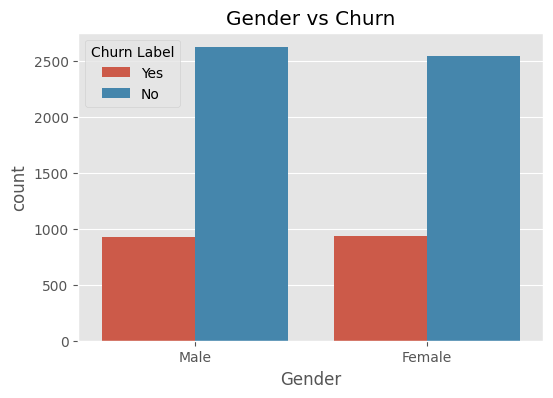

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Churn Label', data=df)
plt.title("Gender vs Churn")
plt.show()